The goal of this Jupyter Notebook is to plot the signifcant coefficient of the regdhfe by market for each output variable.

In [1]:
import pandas as pd

# Import raw csv files

df_won_1 = pd.read_csv('/Users/dvacchini/Library/CloudStorage/Dropbox/Projects_Brazilian_data/Dario_vacchini/data/raw/item_class/reg_won_t_minus_1_by_item_class_1.csv')
df_won_2 = pd.read_csv('/Users/dvacchini/Library/CloudStorage/Dropbox/Projects_Brazilian_data/Dario_vacchini/data/raw/item_class/reg_won_t_minus_1_by_item_class_2.csv')

df_last = pd.read_csv('/Users/dvacchini/Library/CloudStorage/Dropbox/Projects_Brazilian_data/Dario_vacchini/data/raw/item_class/reg_last_bid_by_item_class.csv')

df_age = pd.read_csv('/Users/dvacchini/Library/CloudStorage/Dropbox/Projects_Brazilian_data/Dario_vacchini/data/raw/item_class/reg_age_by_item_class.csv')

df_lim_firm = pd.read_csv('/Users/dvacchini/Library/CloudStorage/Dropbox/Projects_Brazilian_data/Dario_vacchini/data/raw/item_class/reg_limited_firm_by_item_class.csv')

df_90won = pd.read_csv('/Users/dvacchini/Library/CloudStorage/Dropbox/Projects_Brazilian_data/Dario_vacchini/data/raw/item_class/reg_share_won90_by_item_class_1.csv')

In [2]:
# Merge csv files and drop duplicates
df_won = pd.concat([df_won_1, df_won_2], ignore_index=True).drop_duplicates()
df_won = df_won.loc[df_won['Variable'] != '1.flagvencedor#c.MV']
df_last = df_last.loc[df_last['Variable'] != '1.flagvencedor#c.MV']
df_age = df_age.loc[df_age['Variable'] != '1.flagvencedor#c.MV']
df_lim_firm = df_lim_firm.loc[df_lim_firm['Variable'] != '1.flagvencedor#c.MV']

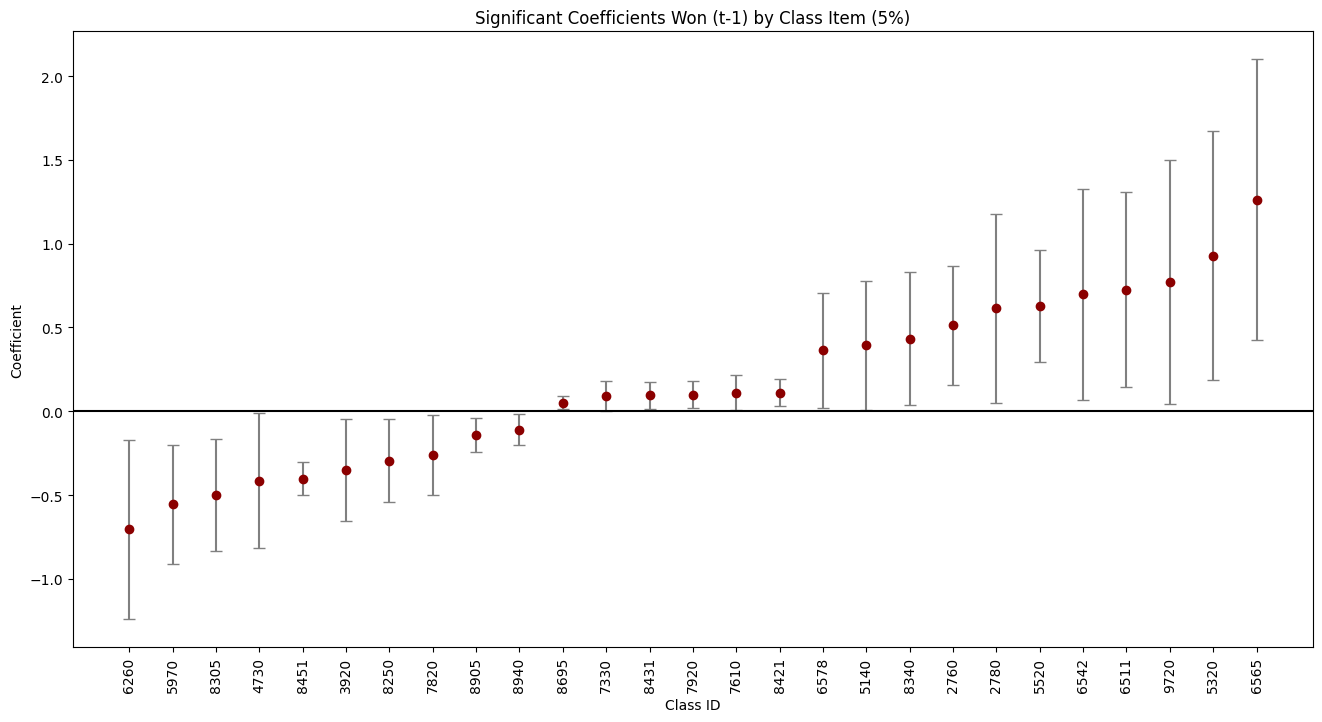

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

# Rename columns if needed to match the example
df_won = df_won.rename(columns={' Class Item': 'class_id', ' Coefficient': 'coefficient', ' Std. Error': 'std_error', ' Sig_1pct': 'sig_1pct', ' Sig_5pct': 'sig_5pct', ' Sig_10pct': 'sig_10pct'})

# Filter rows for significant coefficients (assuming 'sig_1pct' indicates significance)
df_significant = df_won[df_won['sig_5pct'] == 1]

# Sort the dataframe by 'coefficient' in ascending order
df_significant = df_significant.sort_values(by='coefficient', ascending=True)

# Calculate 95% confidence intervals
ci_95 = df_significant['std_error'] * 1.96

# Plot the coefficients with error bars
plt.figure(figsize=(16, 8))
plt.errorbar(range(len(df_significant)), df_significant['coefficient'],  # Use range of sorted index for evenly spaced ticks
             yerr=ci_95, fmt='o', color='darkred', 
             ecolor='gray', capsize=4)

# Add a vertical line at y=0
plt.axhline(y=0, color='black')

# Labels and title
plt.xlabel('Class ID')
plt.ylabel('Coefficient')
plt.title('Significant Coefficients Won (t-1) by Class Item (5%)')

# Set the x-ticks to correspond to the sorted market_id values
plt.xticks(range(len(df_significant)), df_significant['class_id'].astype(str), rotation=90)

# Save the plot as a .pdf file (optional)
plt.savefig('/Users/dvacchini/Library/CloudStorage/Dropbox/Projects_Brazilian_data/Dario_vacchini/output/graphs/coef_sig_won_t_minus_1_item_class_5pct.pdf', bbox_inches='tight', dpi=300)

plt.show()


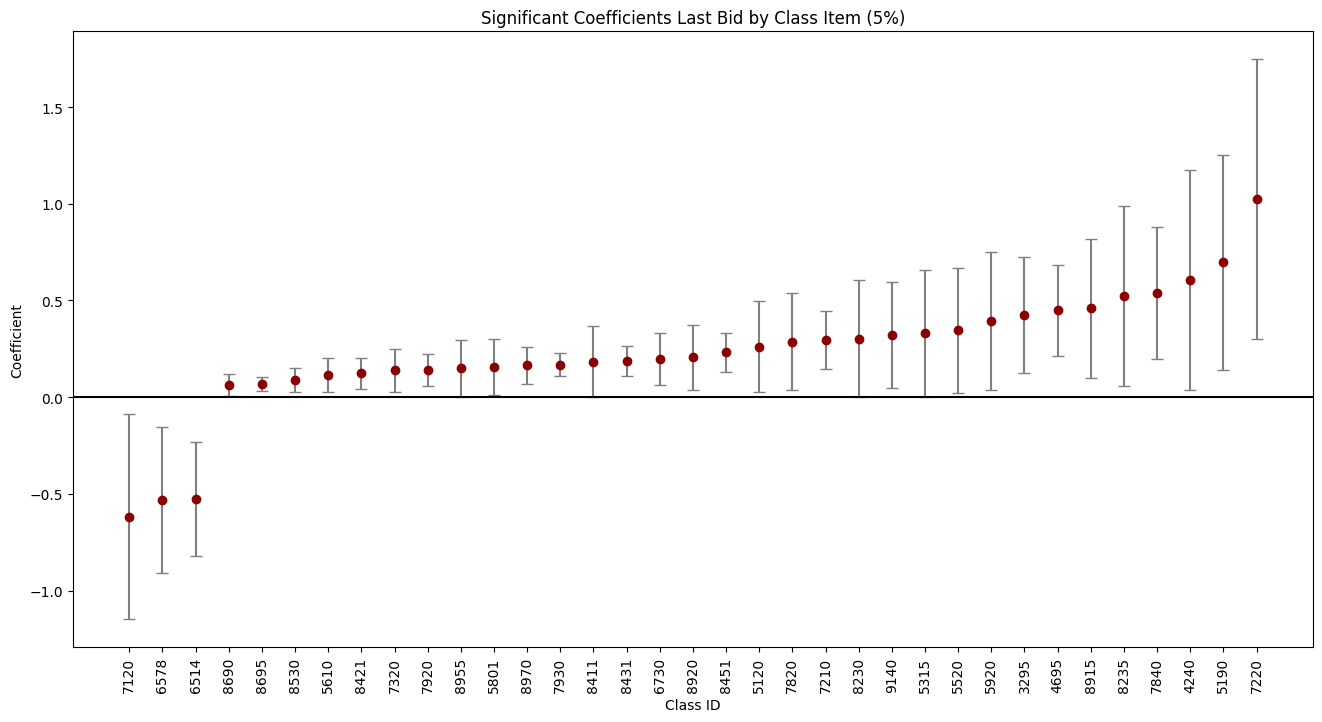

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

# Rename columns if needed to match the example
df_last = df_last.rename(columns={' Class Item': 'class_id', ' Coefficient': 'coefficient', ' Std. Error': 'std_error', ' Sig_1pct': 'sig_1pct', ' Sig_5pct': 'sig_5pct', ' Sig_10pct': 'sig_10pct'})
df_last['class_id'] = df_last['class_id'].astype(int)

# Filter rows for significant coefficients (assuming 'sig_1pct' indicates significance)
df_significant_last = df_last[df_last['sig_5pct'] == 1]

# Sort the dataframe by 'coefficient' in ascending order
df_significant_last = df_significant_last.sort_values(by='coefficient', ascending=True)

# Calculate 95% confidence intervals
ci_95 = df_significant_last['std_error'] * 1.96

# Plot the coefficients with error bars
plt.figure(figsize=(16, 8))
plt.errorbar(range(len(df_significant_last)), df_significant_last['coefficient'],  # Use range of sorted index for evenly spaced ticks
             yerr=ci_95, fmt='o', color='darkred', 
             ecolor='gray', capsize=4)

# Add a vertical line at y=0
plt.axhline(y=0, color='black')

# Labels and title
plt.xlabel('Class ID')
plt.ylabel('Coefficient')
plt.title('Significant Coefficients Last Bid by Class Item (5%)')

# Set the x-ticks to correspond to the sorted market_id values
plt.xticks(range(len(df_significant_last)), df_significant_last['class_id'].astype(int), rotation=90)

# Save the plot as a .pdf file (optional)
plt.savefig('/Users/dvacchini/Library/CloudStorage/Dropbox/Projects_Brazilian_data/Dario_vacchini/output/graphs/coef_sig_last_bid_class_item_5pct.pdf', bbox_inches='tight', dpi=300)

plt.show()

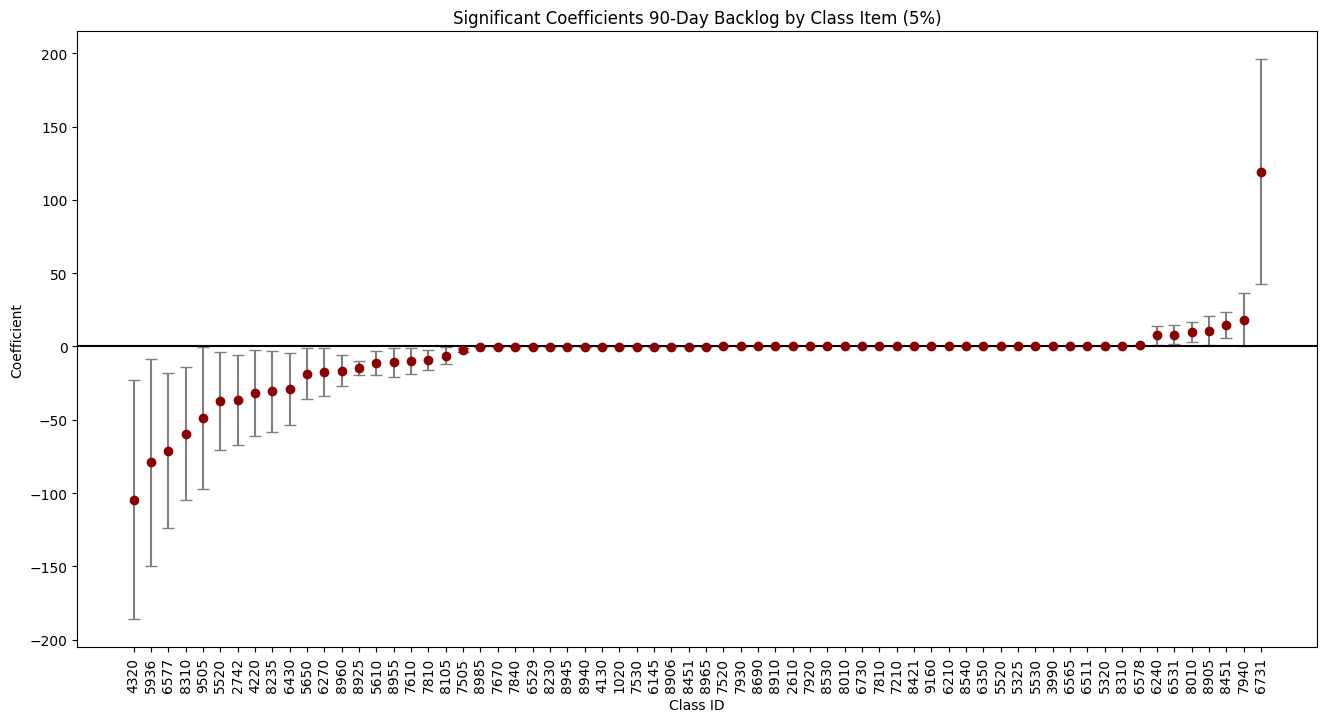

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

# Rename columns if needed to match the example
df_90won = df_90won.rename(columns={' Class Item': 'class_id', ' Coefficient': 'coefficient', ' Std. Error': 'std_error', ' Sig_1pct': 'sig_1pct', ' Sig_5pct': 'sig_5pct', ' Sig_10pct': 'sig_10pct'})
df_90won['class_id'] = df_90won['class_id'].astype(int)

# Filter rows for significant coefficients (assuming 'sig_1pct' indicates significance)
df_significant_last = df_90won[df_90won['sig_5pct'] == 1]

# Sort the dataframe by 'coefficient' in ascending order
df_significant_last = df_significant_last.sort_values(by='coefficient', ascending=True)

# Calculate 95% confidence intervals
ci_95 = df_significant_last['std_error'] * 1.96

# Plot the coefficients with error bars
plt.figure(figsize=(16, 8))
plt.errorbar(range(len(df_significant_last)), df_significant_last['coefficient'],  # Use range of sorted index for evenly spaced ticks
             yerr=ci_95, fmt='o', color='darkred', 
             ecolor='gray', capsize=4)

# Add a vertical line at y=0
plt.axhline(y=0, color='black')

# Labels and title
plt.xlabel('Class ID')
plt.ylabel('Coefficient')
plt.title('Significant Coefficients 90-Day Backlog by Class Item (5%)')

# Set the x-ticks to correspond to the sorted market_id values
plt.xticks(range(len(df_significant_last)), df_significant_last['class_id'].astype(int), rotation=90)

# Save the plot as a .pdf file (optional)
plt.savefig('/Users/dvacchini/Library/CloudStorage/Dropbox/Projects_Brazilian_data/Dario_vacchini/output/graphs/coef_sig_share_90won_class_item_5pct.pdf', bbox_inches='tight', dpi=300)

plt.show()

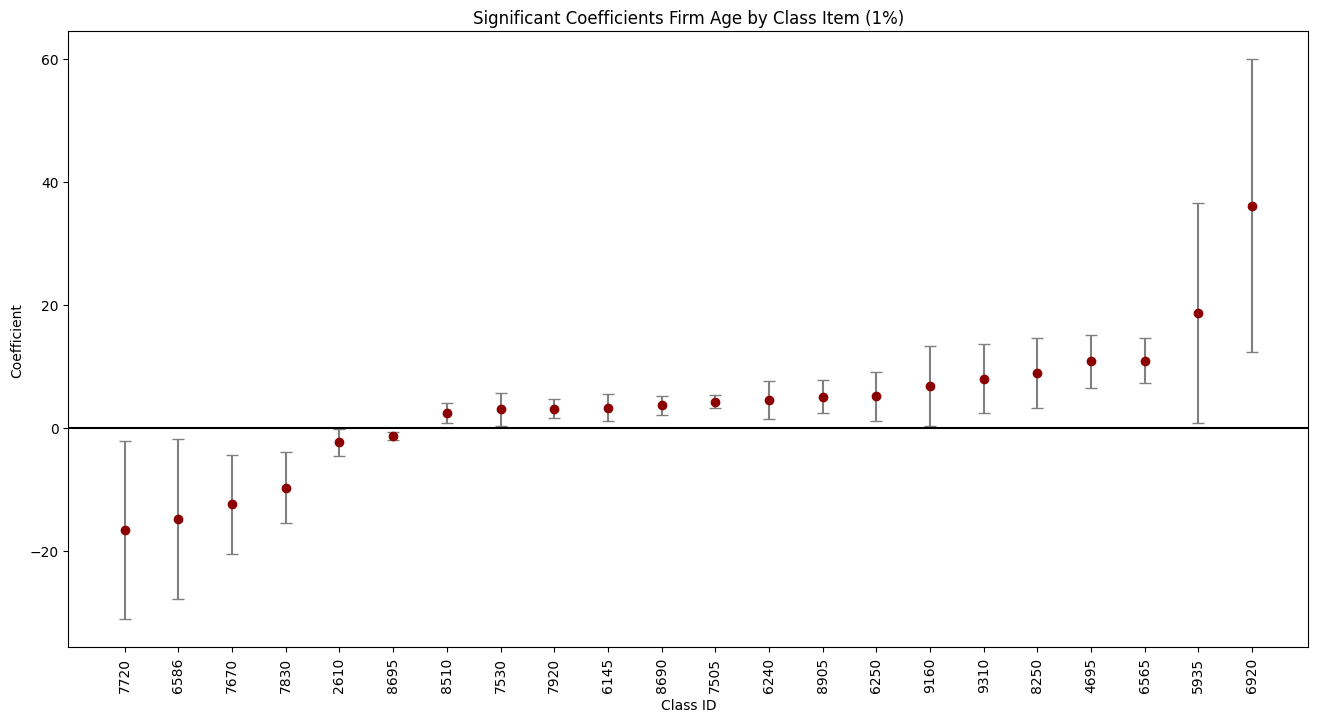

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

# Rename columns if needed to match the example
df_age = df_age.rename(columns={' Class Item': 'class_id', ' Coefficient': 'coefficient', ' Std. Error': 'std_error', ' Sig_1pct': 'sig_1pct', ' Sig_5pct': 'sig_5pct', ' Sig_10pct': 'sig_10pct'})
df_age = df_age[df_age['class_id'] != 6508]
df_age = df_age[df_age['class_id'] != 5345]
df_age = df_age[df_age['class_id'] != 8030]
df_age = df_age[df_age['class_id'] != 6531]
df_age = df_age[df_age['class_id'] != 8990]
df_age = df_age[df_age['class_id'] != 8451]
df_age = df_age[df_age['class_id'] != 8431]
df_age = df_age[df_age['class_id'] != 8421]
df_age = df_age[df_age['class_id'] != 8530]
df_age = df_age[df_age['class_id'] != 8925]
df_age = df_age[df_age['class_id'] != 7930]
df_age = df_age[df_age['class_id'] != 7610]

# Filter rows for significant coefficients (assuming 'sig_1pct' indicates significance)
df_significant_age = df_age[df_age['sig_1pct'] == 1]

# Sort the dataframe by 'coefficient' in ascending order
df_significant_age = df_significant_age.sort_values(by='coefficient', ascending=True)

# Calculate 95% confidence intervals
ci_95 = df_significant_age['std_error'] * 2.54

# Plot the coefficients with error bars
plt.figure(figsize=(16, 8))
plt.errorbar(range(len(df_significant_age)), df_significant_age['coefficient'],  # Use range of sorted index for evenly spaced ticks
             yerr=ci_95, fmt='o', color='darkred', 
             ecolor='gray', capsize=4)

# Add a vertical line at y=0
plt.axhline(y=0, color='black')

# Labels and title
plt.xlabel('Class ID')
plt.ylabel('Coefficient')
plt.title('Significant Coefficients Firm Age by Class Item (1%)')

# Set the x-ticks to correspond to the sorted market_id values
plt.xticks(range(len(df_significant_age)), df_significant_age['class_id'].astype(int), rotation=90)

# Save the plot as a .pdf file (optional)
plt.savefig('/Users/dvacchini/Library/CloudStorage/Dropbox/Projects_Brazilian_data/Dario_vacchini/output/graphs/coef_sig_age_class_item_1pct.pdf', bbox_inches='tight', dpi=300)

plt.show()

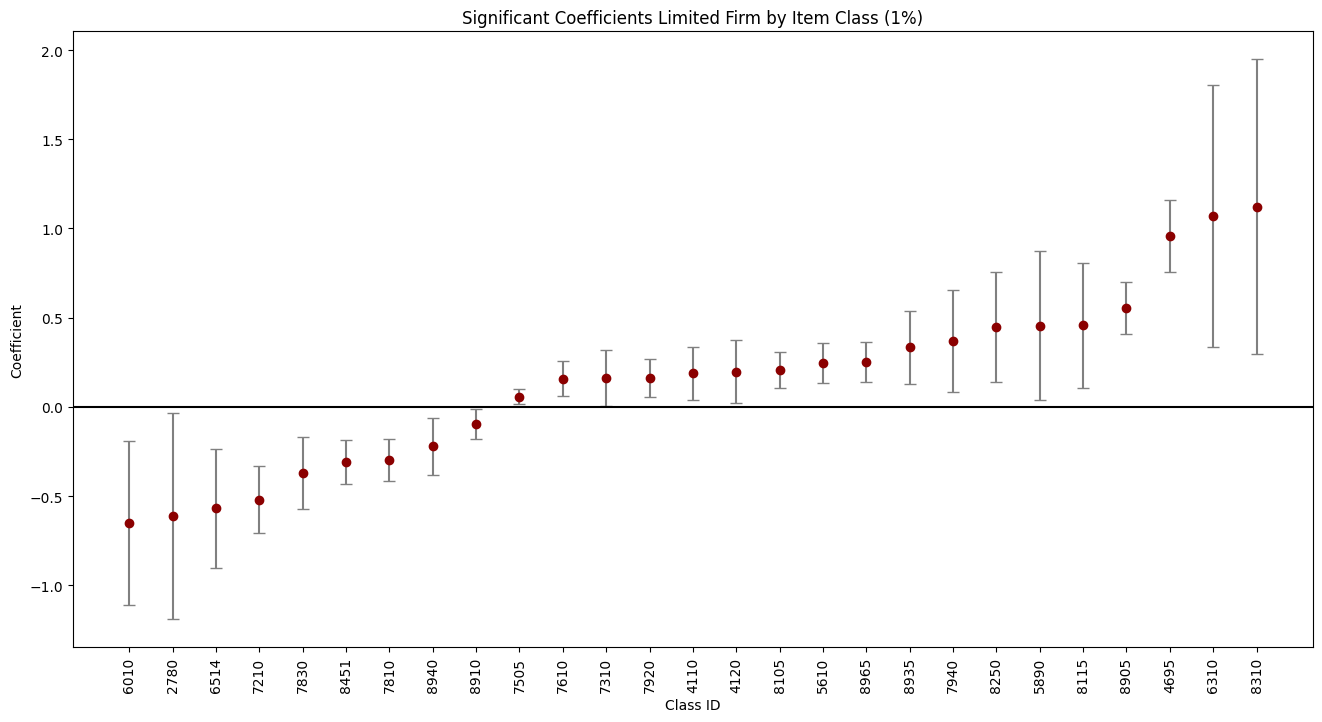

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

# Rename columns if needed to match the example
df_lim_firm = df_lim_firm.rename(columns={' Class Item': 'class_id', ' Coefficient': 'coefficient', ' Std. Error': 'std_error', ' Sig_1pct': 'sig_1pct', ' Sig_5pct': 'sig_5pct', ' Sig_10pct': 'sig_10pct'})
df_lim_firm = df_lim_firm[df_lim_firm['class_id'] != 8145]
df_lim_firm = df_lim_firm[df_lim_firm['class_id'] != 6710]
df_lim_firm = df_lim_firm[df_lim_firm['class_id'] != 4220]
df_lim_firm = df_lim_firm[df_lim_firm['class_id'] != 7130]
df_lim_firm = df_lim_firm[df_lim_firm['class_id'] != 8040]
df_lim_firm = df_lim_firm[df_lim_firm['class_id'] != 1025]
df_lim_firm = df_lim_firm[df_lim_firm['class_id'] != 7930]
df_lim_firm = df_lim_firm[df_lim_firm['class_id'] != 8970]
df_lim_firm = df_lim_firm[df_lim_firm['class_id'] != 7320]
df_lim_firm = df_lim_firm[df_lim_firm['class_id'] != 6526]
df_lim_firm = df_lim_firm[df_lim_firm['class_id'] != 6240]
df_lim_firm = df_lim_firm[df_lim_firm['class_id'] != 8421]

# Filter rows for significant coefficients (assuming 'sig_1pct' indicates significance)
df_significant_lim = df_lim_firm[df_lim_firm['sig_1pct'] == 1]

# Sort the dataframe by 'coefficient' in ascending order
df_significant_lim = df_significant_lim.sort_values(by='coefficient', ascending=True)

# Calculate 95% confidence intervals
ci_95 = df_significant_lim['std_error'] * 2.54

# Plot the coefficients with error bars
plt.figure(figsize=(16, 8))
plt.errorbar(range(len(df_significant_lim)), df_significant_lim['coefficient'],  # Use range of sorted index for evenly spaced ticks
             yerr=ci_95, fmt='o', color='darkred', 
             ecolor='gray', capsize=4)

# Add a vertical line at y=0
plt.axhline(y=0, color='black')

# Labels and title
plt.xlabel('Class ID')
plt.ylabel('Coefficient')
plt.title('Significant Coefficients Limited Firm by Item Class (1%)')

# Set the x-ticks to correspond to the sorted market_id values
plt.xticks(range(len(df_significant_lim)), df_significant_lim['class_id'].astype(int), rotation=90)

# Save the plot as a .pdf file (optional)
plt.savefig('/Users/dvacchini/Library/CloudStorage/Dropbox/Projects_Brazilian_data/Dario_vacchini/output/graphs/coef_sig_limited_firm_item_class_1pct.pdf', bbox_inches='tight', dpi=300)

plt.show()

In [8]:
# Positive coefficient for market - sig: 0.01

positive_significant_markets_won_1 = df_won[(df_won['sig_1pct']==1) & (df_won['coefficient'] > 0)]['class_id'].tolist()
print("won_t_minus_1 (0.01):", positive_significant_markets_won_1)

positive_significant_markets_last_1 = df_last[(df_last['sig_1pct']==1) & (df_last['coefficient'] > 0)]['class_id'].tolist()
print("last (0.01):", positive_significant_markets_last_1)

positive_significant_markets_age_1 = df_age[(df_age['sig_1pct']==1) & (df_age['coefficient'] > 0)]['class_id'].astype(int).to_list()
print("age (0.01):", positive_significant_markets_age_1)

positive_significant_markets_lim_1 = df_lim_firm[(df_lim_firm['sig_1pct']==1) & (df_lim_firm['coefficient'] > 0)]['class_id'].astype(int).to_list()
print("limited_firm (0.01):", positive_significant_markets_lim_1)

won_t_minus_1 (0.01): [2760, 5520, 6565, 8421, 8695]
last (0.01): [3295, 4695, 6730, 7210, 7220, 7840, 7920, 7930, 8421, 8431, 8451, 8530, 8695, 8970]
age (0.01): [4695, 5935, 6145, 6240, 6250, 6565, 6920, 7505, 7530, 7920, 8250, 8510, 8690, 8905, 9160, 9310]
limited_firm (0.01): [4110, 4120, 4695, 5610, 5890, 6310, 7310, 7505, 7610, 7920, 7940, 8105, 8115, 8250, 8310, 8905, 8935, 8965]


In [9]:
# Positive coefficient for market - sig: 0.05

positive_significant_markets_won_5 = df_won[(df_won['sig_5pct']==1) & (df_won['coefficient'] > 0)]['class_id'].tolist()
print("won_t_minus_1 (0.05):", positive_significant_markets_won_5)

positive_significant_markets_last_5 = df_last[(df_last['sig_5pct']==1) & (df_last['coefficient'] > 0)]['class_id'].tolist()
print("last (0.05):", positive_significant_markets_last_5)

positive_significant_markets_age_5 = df_age[(df_age['sig_5pct']==1) & (df_age['coefficient'] > 0)]['class_id'].astype(int).to_list()
print("age (0.05):", positive_significant_markets_age_5)

positive_significant_markets_lim_5 = df_lim_firm[(df_lim_firm['sig_5pct']==1) & (df_lim_firm['coefficient'] > 0)]['class_id'].astype(int).to_list()
print("limited_firm (0.05):", positive_significant_markets_lim_5)

positive_significant_markets_90won_5 = df_90won[(df_90won['sig_5pct']==1) & (df_90won['coefficient'] > 0)]['class_id'].astype(int).to_list()
print("share_90won (0.05):", positive_significant_markets_90won_5)

won_t_minus_1 (0.05): [2760, 2780, 5140, 5320, 5520, 6511, 6542, 6565, 6578, 7330, 7610, 7920, 8340, 8421, 8431, 8695, 9720]
last (0.05): [3295, 4240, 4695, 5120, 5190, 5315, 5520, 5610, 5801, 5920, 6730, 7210, 7220, 7320, 7820, 7840, 7920, 7930, 8230, 8235, 8411, 8421, 8431, 8451, 8530, 8690, 8695, 8915, 8920, 8955, 8970, 9140]
age (0.05): [2710, 4695, 5530, 5935, 6145, 6240, 6250, 6565, 6731, 6920, 7505, 7510, 7515, 7520, 7530, 7920, 8250, 8305, 8510, 8615, 8690, 8730, 8905, 8906, 9160, 9310]
limited_firm (0.05): [3295, 4110, 4120, 4695, 5140, 5610, 5890, 5935, 6310, 6730, 7310, 7505, 7610, 7920, 7940, 8105, 8115, 8135, 8250, 8305, 8310, 8905, 8906, 8935, 8965, 8985]
share_90won (0.05): [2610, 3990, 5320, 5325, 5520, 5530, 6210, 6240, 6350, 6511, 6531, 6565, 6578, 6730, 6731, 7210, 7810, 7920, 7940, 8010, 8010, 8310, 8421, 8451, 8530, 8540, 8690, 8905, 8910, 9160]


In [10]:
# Positive coefficient for market - sig: 0.10

positive_significant_markets_won_10 = df_won[(df_won['sig_10pct']==1) & (df_won['coefficient'] > 0)]['class_id'].tolist()
print("won_t_minus_1 (0.10):", positive_significant_markets_won_10)

positive_significant_markets_last_10 = df_last[(df_last['sig_10pct']==1) & (df_last['coefficient'] > 0)]['class_id'].tolist()
print("last (0.10):", positive_significant_markets_last_10)

positive_significant_markets_age_10 = df_age[(df_age['sig_10pct']==1) & (df_age['coefficient'] > 0)]['class_id'].astype(int).to_list()
print("age (0.10):", positive_significant_markets_age_10)

positive_significant_markets_lim_10 = df_lim_firm[(df_lim_firm['sig_10pct']==1) & (df_lim_firm['coefficient'] > 0)]['class_id'].astype(int).to_list()
print("limited_firm (0.10):", positive_significant_markets_lim_10)

won_t_minus_1 (0.10): [2720, 2760, 2780, 5140, 5320, 5520, 6511, 6542, 6565, 6578, 7330, 7610, 7920, 8340, 8421, 8431, 8690, 8695, 8965, 9310, 9720]
last (0.10): [3295, 4240, 4695, 4730, 5120, 5190, 5315, 5520, 5610, 5801, 5890, 5920, 5935, 6430, 6506, 6508, 6730, 7210, 7220, 7320, 7820, 7840, 7920, 7930, 8230, 8235, 8340, 8411, 8421, 8431, 8451, 8530, 8613, 8690, 8695, 8730, 8905, 8906, 8915, 8920, 8955, 8965, 8970, 9140]
age (0.10): [2710, 2720, 3220, 4695, 5160, 5325, 5530, 5801, 5935, 6145, 6240, 6250, 6529, 6565, 6576, 6731, 6750, 6920, 7505, 7510, 7515, 7520, 7530, 7920, 7940, 8250, 8305, 8510, 8615, 8690, 8730, 8905, 8906, 8940, 8970, 9160, 9310]
limited_firm (0.10): [3295, 3750, 4110, 4120, 4695, 5140, 5610, 5890, 5935, 6310, 6511, 6730, 7105, 7310, 7505, 7610, 7920, 7940, 8105, 8115, 8135, 8250, 8305, 8310, 8690, 8905, 8906, 8935, 8965, 8985]


In [11]:
# Common market -- sig: 0.01 

won_t_minus_1_age_1 = list(set(positive_significant_markets_won_1) & set(positive_significant_markets_age_1))
print("won_t_minus_1 - age (0.01):", won_t_minus_1_age_1)

won_t_minus_1_limited_firm_1 = list(set(positive_significant_markets_won_1) & set(positive_significant_markets_lim_1))
print("won_t_minus_1 - limited_firm (0.01):", won_t_minus_1_limited_firm_1)

last_age_1 = list(set(positive_significant_markets_last_1) & set(positive_significant_markets_age_1))
print("last - age (0.01):", last_age_1)

last_limited_firm_1 = list(set(positive_significant_markets_last_1) & set(positive_significant_markets_lim_1))
print("last - limited_firm (0.01):", last_limited_firm_1)

won_t_minus_1_last_1 = list(set(positive_significant_markets_won_1) & set(positive_significant_markets_last_1))
print("won_t_minus_1 - last (0.01):", won_t_minus_1_last_1)

won_t_minus_1 - age (0.01): [6565]
won_t_minus_1 - limited_firm (0.01): []
last - age (0.01): [7920, 4695]
last - limited_firm (0.01): [7920, 4695]
won_t_minus_1 - last (0.01): [8421, 8695]


In [12]:
# Common market -- sig: 0.05

won_t_minus_1_age_5 = list(set(positive_significant_markets_won_5) & set(positive_significant_markets_age_5))
print("won_t_minus_1 - age (0.05):", won_t_minus_1_age_5)

won_t_minus_1_limited_firm_5 = list(set(positive_significant_markets_won_5) & set(positive_significant_markets_lim_5))
print("won_t_minus_1 - limited_firm (0.05):", won_t_minus_1_limited_firm_5)

last_age_5 = list(set(positive_significant_markets_last_5) & set(positive_significant_markets_age_5))
print("last - limited_firm (0.05):", last_age_5)

last_limited_firm_5 = list(set(positive_significant_markets_last_5) & set(positive_significant_markets_lim_5))
print("last - limited_firm (0.05):", last_limited_firm_5)

won_t_minus_1 - age (0.05): [7920, 6565]
won_t_minus_1 - limited_firm (0.05): [7920, 7610, 5140]
last - limited_firm (0.05): [7920, 8690, 4695]
last - limited_firm (0.05): [5610, 6730, 7920, 4695, 3295]


In [13]:
# Common market -- sig: 0.10

won_t_minus_1_age_10 = list(set(positive_significant_markets_won_10) & set(positive_significant_markets_age_10))
print("won_t_minus_1 - age (0.10):", won_t_minus_1_age_10)

won_t_minus_1_limited_firm_10 = list(set(positive_significant_markets_won_10) & set(positive_significant_markets_lim_10))
print("won_t_minus_1 - limited_firm (0.10):", won_t_minus_1_limited_firm_10)

last_age_10 = list(set(positive_significant_markets_last_10) & set(positive_significant_markets_age_10))
print("last - limited_firm (0.10):", last_age_10)

last_limited_firm_10 = list(set(positive_significant_markets_last_10) & set(positive_significant_markets_lim_10))
print("last - limited_firm (0.10):", last_limited_firm_10)

won_t_minus_1 - age (0.10): [2720, 6565, 7920, 8690, 9310]
won_t_minus_1 - limited_firm (0.10): [8965, 6511, 7920, 8690, 5140, 7610]
last - limited_firm (0.10): [5801, 8970, 8905, 8906, 5935, 7920, 8690, 4695, 8730]
last - limited_firm (0.10): [5890, 8965, 8905, 6730, 8906, 5610, 5935, 7920, 8690, 4695, 3295]
